# PFA - Reconnaissance des Emotions Faciales
## Etape 3 : Data Augmentation

**Equipe :** Ayman TEMSAMANI, Nouhaila AIT ABDELAH, Rabab ZITI  
**Encadrant :** Pr. Redouane DAHBI  
**Date :** Semaine S3-S4 (Phase 2 du planning)

**Contexte :** L'etape precedente a permis de charger les images FER2013 et de les normaliser. Cependant, le dataset presente un desequilibre des classes (ex : la classe 'disgust' contient environ 500 images tandis que 'happy' en contient plus de 7000) et une variabilite limitee des poses et conditions d'eclairage. La data augmentation permet d'augmenter artificiellement la taille et la diversite du jeu d'entrainement en appliquant des transformations aleatoires aux images existantes, sans collecter de nouvelles donnees.

---
### Justification theorique de la data augmentation

**Probleme 1 : Desequilibre des classes.** Dans FER2013, la classe 'disgust' est largement sous-representee (environ 500 images contre 7000+ pour 'happy'). Un modele entraine sur des donnees desequilibrees aura tendance a privilegier les classes majoritaires et a ignorer les classes minoritaires, ce qui degrade le F1-score macro.

**Probleme 2 : Sur-apprentissage (overfitting).** Avec seulement 28 000 images d'entrainement pour 7 classes, un CNN profond risque de memoriser les images plutot que d'apprendre des caracteristiques generales des emotions. La data augmentation force le modele a voir des versions legerement differentes de chaque image a chaque epoque, ce qui agit comme un regularisateur puissant.

**Probleme 3 : Robustesse aux variations.** En conditions reelles (webcam), les visages ne seront jamais parfaitement alignes, centes, et eclaires de maniere uniforme. Sans augmentation, le modele entraine sur des images studio (CK+) ou des images web standardisees (FER2013) echouera face a des variations d'angle, de luminosite ou d'occlusion partielle.

**Solution adoptee :** Application de transformations geometriques et photometriques aleatoires pendant l'entrainement via le parametre `ImageDataGenerator` de Keras. Ces transformations sont appliquees en temps reel, batch par batch, sans augmenter l'occupation disque. Conformement au cahier des charges (Section 4.3), les transformations suivantes sont appliquees :
- Rotation jusqu'a ±15 degres
- Zoom aleatoire entre ×0.9 et ×1.1
- Decalages horizontaux et verticaux de 10%
- Miroir horizontal pour les emotions non asymetriques
- Variation de luminosite entre 80% et 120%

**Note importante :** La data augmentation est appliquee UNIQUEMENT sur les donnees d'entrainement. Les donnees de test ne subissent que la normalisation, afin d'evaluer le modele sur des images reelles, non modifiees.
---

In [11]:
# ============================================================
#  SECTION 1 : Import des bibliotheques necessaires
# ============================================================

# ImageDataGenerator est la classe Keras qui permet de configurer
# les transformations en temps reel sur les images.
# Je l'importe pour creer le generateur avec augmentation.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# matplotlib.pyplot sert a afficher des images.
# Je l'utilise pour visualiser l'effet des augmentations
# sur un echantillon d'images avant l'entrainement.
import matplotlib.pyplot as plt

# numpy est utilise pour la manipulation des tableaux.
# Je m'en sers pour extraire et comparer les images avant/apres augmentation.
import numpy as np

In [12]:
# ============================================================
#  SECTION 2 : Configuration de la data augmentation
# ============================================================

# Je cree un generateur d'entrainement AVEC data augmentation.
# Chaque transformation est appliquee avec une probabilite aleatoire
# a chaque image du batch, ce qui cree une infinite de variantes.
train_datagen_augmented = ImageDataGenerator(
    
    # Normalisation : chaque pixel est divise par 255.
    # Cette transformation est systhematique (probabilite = 1.0).
    # Meme justification qu'a l'etape 2 : stabilite numerique et convergence rapide.
    rescale=1./255,
    
    # rotation_range=15 : rotation aleatoire de l'image jusqu'a ±15 degres.
    # Justification : en conditions reelles (webcam), la tete de l'utilisateur
    # n'est jamais parfaitement droite. Le modele doit apprendre a reconnaitre
    # une emotion meme si le visage est legerement penche.
    # 15 degres est un bon compromis : assez large pour etre utile,
    
    # mais pas trop pour ne pas rendre l'emotion meconnaissable.
    rotation_range=15,
    
    # width_shift_range=0.1 : decalage horizontal aleatoire jusqu'a 10%
    # de la largeur de l'image.
    # Justification : le visage peut ne pas etre parfaitement centre
    # dans le cadre de la webcam. Ce decalage simule cette variation.
    width_shift_range=0.1,
    
    # height_shift_range=0.1 : decalage vertical aleatoire jusqu'a 10%
    # de la hauteur de l'image.
    # Meme justification que pour le decalage horizontal.
    height_shift_range=0.1,
    
    # zoom_range=0.1 : zoom aleatoire entre ×0.9 et ×1.1.
    # 0.1 signifie un facteur multiplicatif entre 1-0.1=0.9 et 1+0.1=1.1.
    # Justification : la distance entre le visage et la camera varie
    # selon l'utilisateur. Le zoom simule ces variations de distance.
    zoom_range=0.1,
    
    # horizontal_flip=True : miroir horizontal applique aleatoirement
    # a 50% des images.
    # Justification : une emotion est generalement symetrique.
    # Un visage vu en miroir exprime la meme emotion.
    # Attention : cette transformation n'est pas adaptee aux emotions
    # asymetriques (ex : wink/clin d'oeil), mais FER2013 n'en contient pas.
    horizontal_flip=True,
    
    # brightness_range=[0.8, 1.2] : variation de luminosite entre 80% et 120%
    # de la luminosite originale.
    # Justification : les conditions d'eclairage varient enormement
    # en utilisation reelle (bureau sombre, exterieur ensoleille, etc.).
    # Cette transformation rend le modele robuste aux changements de luminosite.
    brightness_range=[0.8, 1.2],
    
    # fill_mode='nearest' : strategie de remplissage des pixels vides
    # apres une rotation ou un decalage.
    # 'nearest' utilise la valeur du pixel le plus proche.
    # Alternatives : 'constant' (remplit avec une constante, ex: 0),
    # 'reflect' (reflete l'image comme un miroir sur les bords).
    fill_mode='nearest'
)

# Je cree un generateur de test SANS data augmentation.
# Seule la normalisation est appliquee, comme a l'etape 2.
# Principe fondamental : le test doit refleter les conditions reelles,
# donc les images de test ne doivent pas etre modifiees artificiellement.
test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
# ============================================================
#  SECTION 3 : Chargement des donnees avec augmentation
# ============================================================

print("=" * 60)
print("CHARGEMENT DU JEU D'ENTRAINEMENT AVEC DATA AUGMENTATION")
print("=" * 60)

# Je charge les images d'entrainement en utilisant le generateur
# qui contient les parametres d'augmentation.
# flow_from_directory() applique les transformations definies
# dans train_datagen_augmented a chaque image lue.
train_generator_augmented = train_datagen_augmented.flow_from_directory(
    
    # Chemin vers le dossier d'entrainement.
    # Meme dossier que l'etape 2.
    'C:/Users/ayman/Desktop/PFA/archive/train',
    
    # Taille cible identique a l'etape 2 : 48x48 pixels.
    target_size=(48, 48),
    
    # Niveaux de gris pour les memes raisons qu'a l'etape 2.
    color_mode='grayscale',
    
    # One-hot encoding pour la classification multi-classe.
    class_mode='categorical',
    
    # Taille de batch maintenue a 32.
    batch_size=32,
    
    # Melange des images pour eviter que le modele apprenne l'ordre.
    shuffle=True
)

print("\n" + "=" * 60)
print("CHARGEMENT DU JEU DE TEST (SANS AUGMENTATION)")
print("=" * 60)

# Je charge les images de test avec le generateur sans augmentation.
# Ce generateur est identique a celui de l'etape 2.
test_generator = test_datagen.flow_from_directory(
    'C:/Users/ayman/Desktop/PFA/archive/test',
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

CHARGEMENT DU JEU D'ENTRAINEMENT AVEC DATA AUGMENTATION
Found 28709 images belonging to 7 classes.

CHARGEMENT DU JEU DE TEST (SANS AUGMENTATION)
Found 7178 images belonging to 7 classes.


In [14]:
# ============================================================
#  SECTION 4 : Verification des generateurs
# ============================================================

print("\n" + "=" * 60)
print("VERIFICATION DES GENERATEURS")
print("=" * 60)

# Je verifie que le mapping des classes est identique a l'etape 2.
# L'ordre alphabetique des sous-dossiers garantit cette coherence.
print("\nMapping des classes (nom -> indice) :")
print(train_generator_augmented.class_indices)

# Nombre d'images identique a l'etape 2.
print(f"\nNombre d'images d'entrainement : {train_generator_augmented.samples}")
print(f"Nombre d'images de test          : {test_generator.samples}")

# Nombre de batchs identique a l'etape 2.
print(f"\nNombre de batchs par epoque (train) : {len(train_generator_augmented)}")
print(f"Nombre de batchs par epoque (test)  : {len(test_generator)}")


VERIFICATION DES GENERATEURS

Mapping des classes (nom -> indice) :
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Nombre d'images d'entrainement : 28709
Nombre d'images de test          : 7178

Nombre de batchs par epoque (train) : 898
Nombre de batchs par epoque (test)  : 225


VISUALISATION DES EFFETS DE LA DATA AUGMENTATION

Les 8 images ci-dessous proviennent du MEME batch.
Chacune a subi des transformations aleatoires differentes :
rotation, zoom, decalage, miroir, luminosite.

Si vous re-executez cette cellule, vous verrez de nouvelles variantes.


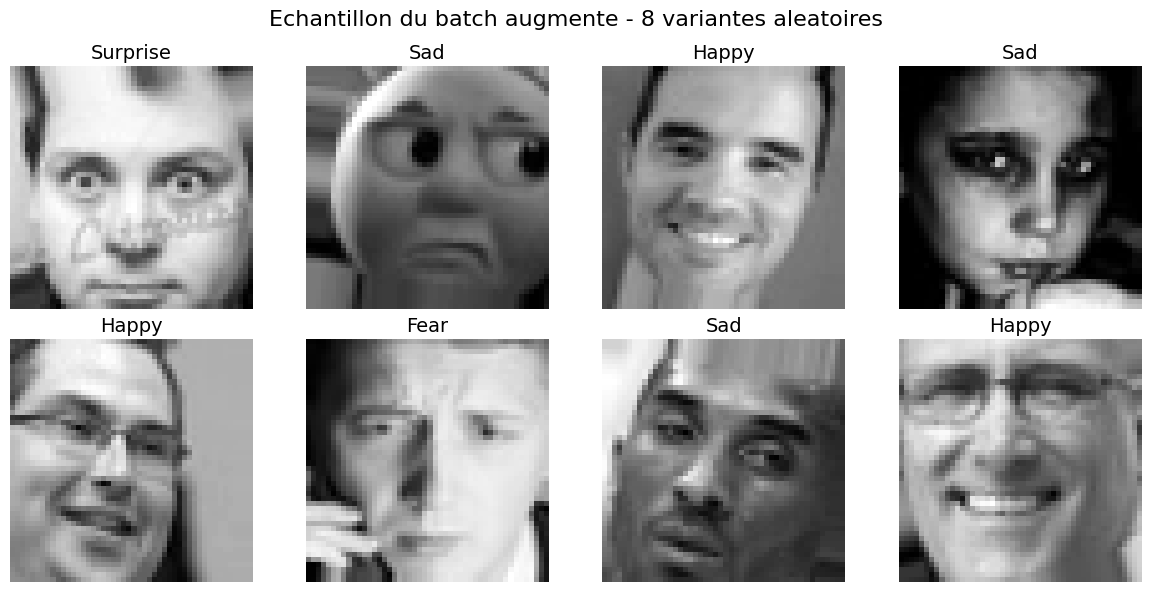


Remarque : Les differences sont parfois subtiles sur des images 48x48.
L'effet est plus visible sur des resolutions superieures (ex : 224x224).
Neanmoins, ces transformations ameliorent significativement la robustesse du modele.


In [15]:
# ============================================================
#  SECTION 5 : Visualisation de l'effet de l'augmentation
# ============================================================

# Pour visualiser l'augmentation, je prends UNE seule image
# et je la passe plusieurs fois dans le generateur.
# Chaque passage applique des transformations aleatoires differentes.
# Cela permet de voir concretement la diversite creee par l'augmentation.

# Je prends un batch du generateur d'entrainement.
images_batch, labels_batch = next(train_generator_augmented)

# Je selectionne la premiere image du batch.
# Sa forme est (48, 48, 1).
# Je la stocke pour l'afficher comme reference "originale".
# Note : cette image a DEJA subi une augmentation aleatoire
# car elle vient du generateur augmente.
# Mais on peut voir differentes variantes en prenant d'autres
# images du meme batch, ou en re-executant cette cellule.

print("=" * 60)
print("VISUALISATION DES EFFETS DE LA DATA AUGMENTATION")
print("=" * 60)
print("\nLes 8 images ci-dessous proviennent du MEME batch.")
print("Chacune a subi des transformations aleatoires differentes :")
print("rotation, zoom, decalage, miroir, luminosite.")
print("\nSi vous re-executez cette cellule, vous verrez de nouvelles variantes.")

# Dictionnaire pour convertir les indices en noms d'emotions.
idx_to_emotion = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Neutral',
    5: 'Sad',
    6: 'Surprise'
}

# J'affiche 8 images du batch pour montrer la diversite.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    
    # Extraction de l'image i du batch.
    # [:, :, 0] enleve la dimension du canal pour obtenir (48, 48).
    img = images_batch[i][:, :, 0]
    
    # Extraction du label via argmax sur le vecteur one-hot.
    label_idx = np.argmax(labels_batch[i])
    emotion = idx_to_emotion[label_idx]
    
    # Affichage de l'image en niveaux de gris.
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(emotion, fontsize=14)
    axes[i].axis('off')

plt.suptitle('Echantillon du batch augmente - 8 variantes aleatoires', fontsize=16)
plt.tight_layout()
plt.show()

print("\nRemarque : Les differences sont parfois subtiles sur des images 48x48.")
print("L'effet est plus visible sur des resolutions superieures (ex : 224x224).")
print("Neanmoins, ces transformations ameliorent significativement la robustesse du modele.")


DEMONSTRATION : 8 VARIANTES D'UNE MEME IMAGE

Je recupere UNE seule image source SANS normalisation.
Puis je la passe 8 fois dans le generateur d'augmentation AVEC normalisation.
Chaque passage applique des transformations aleatoires differentes.

Found 28709 images belonging to 7 classes.


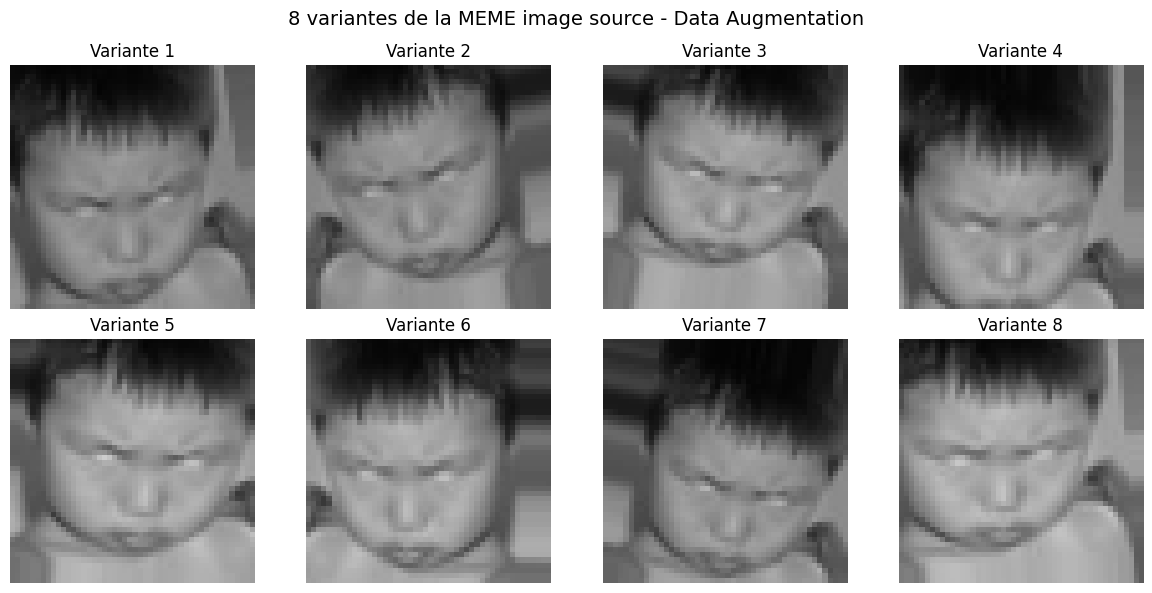


Les 8 images ci-dessus sont toutes issues de la MEME image source.
Les differences (rotation, zoom, luminosite, miroir) sont dues a l'augmentation.


In [16]:
# ============================================================
#  SECTION 6 : Demonstration de l'augmentation sur une image unique
# ============================================================

print("\n" + "=" * 60)
print("DEMONSTRATION : 8 VARIANTES D'UNE MEME IMAGE")
print("=" * 60)
print("\nJe recupere UNE seule image source SANS normalisation.")
print("Puis je la passe 8 fois dans le generateur d'augmentation AVEC normalisation.")
print("Chaque passage applique des transformations aleatoires differentes.\n")

# Etape 1 : Generateur SANS augmentation ET SANS normalisation pour recuperer l'image brute
datagen_source = ImageDataGenerator()  # AUCUN rescale : on garde les pixels 0-255

source_generator = datagen_source.flow_from_directory(
    'C:/Users/ayman/Desktop/PFA/archive/train',
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=1,
    shuffle=False
)

# Je prends la premiere image (brute, pixels 0-255)
source_img, source_label = next(source_generator)

# Etape 2 : Generateur AVEC augmentation ET normalisation
# Le rescale=1./255 normalise les pixels apres les transformations
datagen_aug = ImageDataGenerator(
    rescale=1./255,          # Normalisation APRES toutes les transformations
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# .flow() applique les transformations + normalisation a chaque appel
single_img_generator = datagen_aug.flow(source_img, batch_size=1)

# Etape 3 : Afficher 8 variantes de la meme image
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    # next() applique transformations + normalisation a l'image source brute
    img_augmented = next(single_img_generator)
    
    # img_augmented est un batch de 1 image, forme (1, 48, 48, 1)
    # Les valeurs sont dans [0, 1] grace au rescale
    img = img_augmented[0, :, :, 0]
    
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'Variante {i+1}', fontsize=12)
    axes[i].axis('off')

plt.suptitle('8 variantes de la MEME image source - Data Augmentation', fontsize=14)
plt.tight_layout()
plt.show()

print("\nLes 8 images ci-dessus sont toutes issues de la MEME image source.")
print("Les differences (rotation, zoom, luminosite, miroir) sont dues a l'augmentation.")

In [17]:
# ============================================================
#  SECTION 7 : Verification de la normalisation preservee
# ============================================================

print("\n" + "=" * 60)
print("VERIFICATION DE LA NORMALISATION APRES AUGMENTATION")
print("=" * 60)

# Je prends un batch pour verifier que la normalisation est toujours
# dans l'intervalle [0, 1] meme apres les transformations.
images_check, labels_check = next(train_generator_augmented)

print(f"\nForme du batch : {images_check.shape}")
print(f"Valeur minimale : {images_check.min():.4f}")
print(f"Valeur maximale : {images_check.max():.4f}")
print(f"Type de donnees : {images_check.dtype}")

# Verification logique : si la normalisation a fonctionne,
# les valeurs doivent etre dans [0, 1].
if images_check.min() >= 0.0 and images_check.max() <= 1.0:
    print("\nNormalisation OK - Valeurs dans l'intervalle [0, 1].")
else:
    print("\nATTENTION : La normalisation semble incorrecte.")
    print("Verifier le parametre rescale dans le generateur.")


VERIFICATION DE LA NORMALISATION APRES AUGMENTATION

Forme du batch : (32, 48, 48, 1)
Valeur minimale : 0.0000
Valeur maximale : 1.0000
Type de donnees : float32

Normalisation OK - Valeurs dans l'intervalle [0, 1].


In [18]:
# ============================================================
#  SECTION 8 : Bilan de l'etape 3
# ============================================================

print("\n" + "=" * 60)
print("BILAN DE L'ETAPE 3 - DATA AUGMENTATION")
print("=" * 60)

print("""
Operations realisees dans cette etape :

  1. Configuration du generateur d'entrainement avec data augmentation :
     - Normalisation rescale=1./255 (conservee de l'etape 2)
     - Rotation jusqu'a ±15 degres
     - Decalage horizontal jusqu'a 10%
     - Decalage vertical jusqu'a 10%
     - Zoom aleatoire entre ×0.9 et ×1.1
     - Miroir horizontal aleatoire
     - Variation de luminosite entre 80% et 120%
     - Remplissage des bords en mode 'nearest'
  2. Conservation du generateur de test SANS augmentation
  3. Chargement des donnees avec les nouveaux generateurs
  4. Verification du mapping des classes et du nombre d'images
  5. Visualisation des effets de l'augmentation sur un echantillon
  6. Demonstration de 8 variantes d'une meme image source
  7. Verification que la normalisation est preservee apres augmentation

Justification des transformations choisies :
  - Rotation ±15deg : robustesse a l'inclinaison de tete
  - Decalages 10% : robustesse au cadrage imparfait
  - Zoom 0.9-1.1 : robustesse a la distance variable du visage
  - Miroir horizontal : symetrie des expressions faciales
  - Luminosite 0.8-1.2 : robustesse aux conditions d'eclairage

Prochaines etapes :
  -> Etape 4 : Construction du modele CNN
     Avec les generateurs augmentes, le modele verra des images
     differentes a chaque epoque, ce qui ameliorera sa generalisation.
""")

print("=" * 60)
print("ETAPE 3 TERMINEE - DATA AUGMENTATION CONFIGUREE")
print("=" * 60)


BILAN DE L'ETAPE 3 - DATA AUGMENTATION

Operations realisees dans cette etape :

  1. Configuration du generateur d'entrainement avec data augmentation :
     - Normalisation rescale=1./255 (conservee de l'etape 2)
     - Rotation jusqu'a ±15 degres
     - Decalage horizontal jusqu'a 10%
     - Decalage vertical jusqu'a 10%
     - Zoom aleatoire entre ×0.9 et ×1.1
     - Miroir horizontal aleatoire
     - Variation de luminosite entre 80% et 120%
     - Remplissage des bords en mode 'nearest'
  2. Conservation du generateur de test SANS augmentation
  3. Chargement des donnees avec les nouveaux generateurs
  4. Verification du mapping des classes et du nombre d'images
  5. Visualisation des effets de l'augmentation sur un echantillon
  6. Demonstration de 8 variantes d'une meme image source
  7. Verification que la normalisation est preservee apres augmentation

Justification des transformations choisies :
  - Rotation ±15deg : robustesse a l'inclinaison de tete
  - Decalages 10% : ro